# CIBUSmod example
This notebook privides an example of using CIBUSmod to run a number of scenarios that represent different combinations of demand and production-side "intervetions". For more thorough explanations see 'run_scn.ipynb'

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Run test scenario 'food-as-industry'

### Set up scenario and modules

Set path to folders containing all default and scenario data. Here we define a number of scenarios based on the same scenario Excel file but where we chose which madules and parameters are uppdated.

In [3]:
# Create session
session = cm.Session(
    name = 'food_as_industry_measures',
    data_path = '../data'
)


# Define scenarios 
session.add_scenario(
    name = 'baseline',
    years = '2020'
)
session.add_scenario(
    name = 'FAI (demand)',                            # Name of scenario in outputs
    scenario = 'food_as_industry',                    # Name of scenario Excel file
    modules = ['Regions','DemandAndConversions'],     # Modules to update
    years = '2050'                                    # Years to calculate (= 2020-2050 with 10-year time-steps)
)
session.add_scenario(
    name = 'FAI (+crop yields)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction'],
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+milk yield)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd'],
    pars = {
        'CattleHerd':['milk_prod'] # Only update 'milk_prod' parameter in CattleHerds
    },              
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+beef productivity)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight']
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+pork productivity)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight']
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+enteric methane)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd','FeedMgmt'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight'],
        'FeedMgmt' : 'enteric_adj'
    },
    years = '2050'
)
session.add_scenario(
    name = 'FAI (+electric field machinery)',
    scenario = 'food_as_industry',
    modules = ['Regions','DemandAndConversions','CropProduction',
              'CattleHerd','PigHerd','FeedMgmt','MachineryAndEnergyMgmt'],
    pars = {
        'CattleHerd':['milk_prod',
                      'slaughter_share_male_as_steers','slaughter_weight'],
        'FeedMgmt' : 'enteric_adj'
    },
    years = '2050'
)

session

A scenario with the name baseline already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (demand) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+crop yields) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+milk yield) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+beef productivity) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+pork productivity) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+enteric methane) already exists use .update_scenario() or .remove_scenario() first.
A scenario with the name FAI (+electric field machinery) already exists use .update_scenario() or .remove_scenario() first.


+------------------+
| CIBUSmod SESSION |
+------------------+
Name: food_as_industry_measures

SCENARIOS
baseline: 2020 [has output]
FAI (demand): 2050 [has output]
FAI (+crop yields): 2050 [has output]
FAI (+milk yield): 2050 [has output]
FAI (+beef productivity): 2050 [has output]
FAI (+pork productivity): 2050 [has output]
FAI (+enteric methane): 2050 [has output]
FAI (+electric field machinery): 2050 [has output]

OUTPUT DATA
DemandAndConversions
--------------------
ATTR                         UNIT        ORIG                    DESC                                                                          
population                   millions    DemandAndConversions    Human population                                                              
food_demand                  kg/year     DemandAndConversions    Demand for food per production system and origin (domestic, imported)         
food_demand_to_processing    kg/year     DemandAndConversions    Food demand after accounti

Next, we initialise all model modules (python classes) that handle the calculations.

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

### Run calculations

In [5]:
# Set to true to print progress messages
msg = True

# Loop through scenarios and years
for scn, year in session.iterate('all'):
    print(scn,year)

    # Update all parameter values
    cm.ParameterRetriever.update_all_parameter_values(
        **session[scn],
        year=year
    )

    # Get region attributes
    regions.calculate(verbose=msg)

    # Calculate food demand
    demand.calculate(verbose=msg)

    # Calculate crops
    crops.calculate(
        verbose=msg
    )

    # Calculate herds
    for h in herds:
        h.calculate(verbose=msg)

    # Calculate feed
    feed_mgmt.calculate(verbose=msg)    

    # Distribute animals and crops
    # Make optimisation problem
    geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=msg)
    # Solve optimisation problem
    geodist.solve(
        verbose=msg,
        solver_settings = {
            'solver':'OSQP',
            'max_iter':200000,
            'eps_abs':5e-6,
            'eps_rel':5e-6,
            'verbose':False
        }
    )

    # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
    feed_mgmt.calculate2(verbose=msg)

    # Calculate manure
    manure_mgmt.calculate(verbose=msg)

    # Calculate harvest of crop residues
    crop_residue_mgmt.calculate(verbose=msg)

    # Calculate plant nutrient management
    plant_nutrient_mgmt.calculate(verbose=msg)

    # Calculate energy requirements
    machinery_and_energy_mgmt.calculate(verbose=msg)

    # Calculate inputs supply chain emissions
    inputs.calculate(verbose=msg)

    # Store results
    session.store(
        scn, year,
        demand, regions, crops, herds
    )

baseline 2020
[06:08:34][Regions] Getting initial crop areas and animal numbers (x0) ...
[06:08:34][Regions] Getting climate and soil attributes ...
[06:08:35][Regions] Calculating maximum land use ...
[06:08:35][Regions] Done! Elapsed time: 1 sec
[06:08:35][DemandAndConversions] Calculating food demand ...
[06:08:35][DemandAndConversions] Calculating waste ...
[06:08:35][DemandAndConversions] Calculating crop product demand ...
[06:08:36][DemandAndConversions] Calculating animal product demand ...
[06:08:37][DemandAndConversions] Done! Elapsed time: 2 sec
[06:08:37][CropProduction] Calculating harvest ...
[06:08:37][CropProduction] Calculating production ...
[06:08:41][CropProduction] Calculating crop residues ...
[06:08:41][CropProduction] Calculating seed demand ...
[06:08:42][CropProduction] Done! Elapsed time: 5 sec
[06:08:42][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ...
[06:08:43][AnimalHerd (cattle, beef, conventional, ley based)] Calculatin

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.fertiliser.mineral_K_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')


Outputs stored!
FAI (demand) 2050
[06:15:48][Regions] Getting initial crop areas and animal numbers (x0) ...
[06:15:48][Regions] Getting climate and soil attributes ...
[06:15:48][Regions] Calculating maximum land use ...
[06:15:49][Regions] Done! Elapsed time: 0 sec
[06:15:49][DemandAndConversions] Calculating food demand ...
[06:15:49][DemandAndConversions] Calculating waste ...
[06:15:49][DemandAndConversions] Calculating crop product demand ...
[06:15:49][DemandAndConversions] Calculating animal product demand ...
[06:15:50][DemandAndConversions] Done! Elapsed time: 1 sec
[06:15:50][CropProduction] Calculating harvest ...
[06:15:50][CropProduction] Calculating production ...
[06:15:53][CropProduction] Calculating crop residues ...
[06:15:53][CropProduction] Calculating seed demand ...
[06:15:54][CropProduction] Done! Elapsed time: 5 sec
[06:15:54][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ...
[06:15:55][AnimalHerd (cattle, beef, conventional, le

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.fertiliser.mineral_K_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')


Outputs stored!
FAI (+crop yields) 2050
[06:21:36][Regions] Getting initial crop areas and animal numbers (x0) ...
[06:21:36][Regions] Getting climate and soil attributes ...
[06:21:36][Regions] Calculating maximum land use ...
[06:21:36][Regions] Done! Elapsed time: 0 sec
[06:21:36][DemandAndConversions] Calculating food demand ...
[06:21:36][DemandAndConversions] Calculating waste ...
[06:21:36][DemandAndConversions] Calculating crop product demand ...
[06:21:36][DemandAndConversions] Calculating animal product demand ...
[06:21:37][DemandAndConversions] Done! Elapsed time: 1 sec
[06:21:37][CropProduction] Calculating harvest ...
[06:21:37][CropProduction] Calculating production ...
[06:21:41][CropProduction] Calculating crop residues ...
[06:21:41][CropProduction] Calculating seed demand ...
[06:21:42][CropProduction] Done! Elapsed time: 5 sec
[06:21:42][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ...
[06:21:42][AnimalHerd (cattle, beef, convention

...

Outputs stored!
FAI (+enteric methane) 2050
[06:45:17][Regions] Getting initial crop areas and animal numbers (x0) ...
[06:45:17][Regions] Getting climate and soil attributes ...
[06:45:17][Regions] Calculating maximum land use ...
[06:45:18][Regions] Done! Elapsed time: 0 sec
[06:45:18][DemandAndConversions] Calculating food demand ...
[06:45:18][DemandAndConversions] Calculating waste ...
[06:45:18][DemandAndConversions] Calculating crop product demand ...
[06:45:18][DemandAndConversions] Calculating animal product demand ...
[06:45:18][DemandAndConversions] Done! Elapsed time: 1 sec
[06:45:18][CropProduction] Calculating harvest ...
[06:45:18][CropProduction] Calculating production ...
[06:45:21][CropProduction] Calculating crop residues ...
[06:45:21][CropProduction] Calculating seed demand ...
[06:45:22][CropProduction] Done! Elapsed time: 4 sec
[06:45:22][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ...
[06:45:23][AnimalHerd (cattle, beef, conven

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.fertiliser.mineral_K_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')


Outputs stored!
FAI (+electric field machinery) 2050
[06:50:52][Regions] Getting initial crop areas and animal numbers (x0) ...
[06:50:52][Regions] Getting climate and soil attributes ...
[06:50:52][Regions] Calculating maximum land use ...
[06:50:52][Regions] Done! Elapsed time: 0 sec
[06:50:52][DemandAndConversions] Calculating food demand ...
[06:50:52][DemandAndConversions] Calculating waste ...
[06:50:52][DemandAndConversions] Calculating crop product demand ...
[06:50:53][DemandAndConversions] Calculating animal product demand ...
[06:50:53][DemandAndConversions] Done! Elapsed time: 1 sec
[06:50:53][CropProduction] Calculating harvest ...
[06:50:53][CropProduction] Calculating production ...
[06:50:56][CropProduction] Calculating crop residues ...
[06:50:56][CropProduction] Calculating seed demand ...
[06:50:58][CropProduction] Done! Elapsed time: 4 sec
[06:50:58][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ...
[06:50:58][AnimalHerd (cattle, bee

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\CIBUSmod\notebooks\..\CIBUSmod\utils\session_db.py:724: UserWarning: NaNs in CropProduction.fertiliser.mineral_K_supply_chain_emissions. Set to zero
  warnings.warn(f'NaNs in {module.par.name}.{attr}. Set to zero')


Outputs stored!


### Look at the data

In [6]:
session

+------------------+
| CIBUSmod SESSION |
+------------------+
Name: food_as_industry_measures

SCENARIOS
baseline: 2020 [has output]
FAI (demand): 2050 [has output]
FAI (+crop yields): 2050 [has output]
FAI (+milk yield): 2050 [has output]
FAI (+beef productivity): 2050 [has output]
FAI (+pork productivity): 2050 [has output]
FAI (+enteric methane): 2050 [has output]
FAI (+electric field machinery): 2050 [has output]

OUTPUT DATA
DemandAndConversions
--------------------
ATTR                         UNIT        ORIG                    DESC                                                                          
population                   millions    DemandAndConversions    Human population                                                              
food_demand                  kg/year     DemandAndConversions    Demand for food per production system and origin (domestic, imported)         
food_demand_to_processing    kg/year     DemandAndConversions    Food demand after accounti

## Plot output
Here are some example output plots.

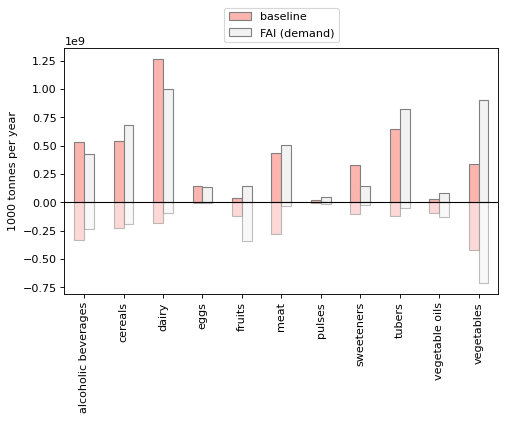

In [7]:
plot_data = (
    session.get_attr('D','food_demand_to_processing',['origin','food_group']).loc[['baseline','FAI (demand)']]
    .stack()
    .droplevel('year')
)
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

fig, ax = plt.subplots(figsize=(7,4), dpi=80)
plot_data['domestic'].unstack('scn').plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax)
(
    plot_data['imported'].unstack('scn')
    .rename({x:'_' for x in plot_data.index.get_level_values('scn').unique()}, axis=1)
).plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax, legend=False, alpha=0.5)

plt.hlines(0,-1,11, color='black', linewidth=1)
ax.tick_params(axis='both', which='major')
ax.set_ylabel('1000 tonnes per year')
ax.set_xlabel('')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), fontsize=10)

plt.show()

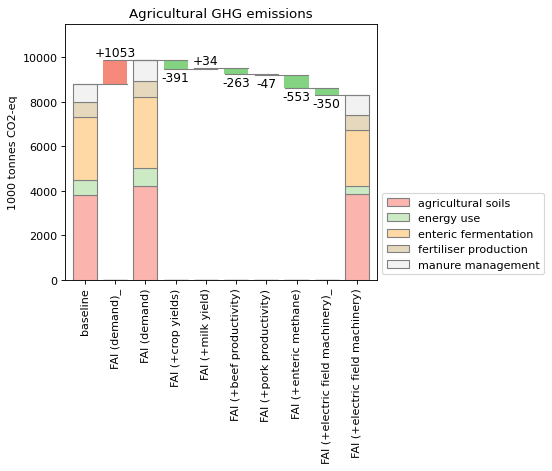

In [8]:
fig, ax = plt.subplots(figsize=(7,6), dpi=80)

plot_data1 = (
    cm.get_GHG(session)
    .groupby('process', axis=1).sum()
    .droplevel('year')
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Agricultural GHG emissions')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes CO2-eq')
ax.set_ylim(top=11500)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

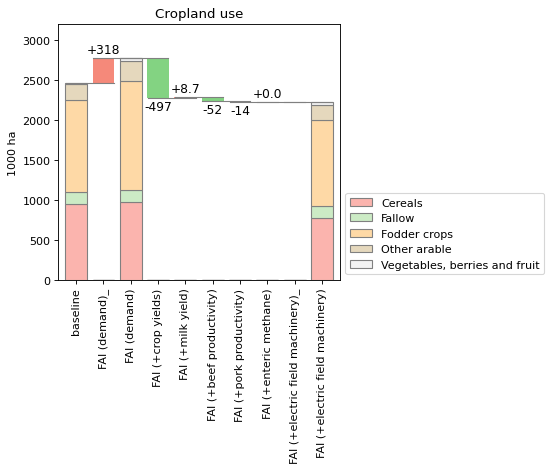

In [9]:
fig, ax = plt.subplots(figsize=(7,6), dpi=80)

plot_data2 = (
    (session.get_attr('C','area',groupby={'crop':'crop_group2'})/1000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1)
    .droplevel('year')
)

plot.waterfall(
    data=plot_data2,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Cropland use')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 ha')
ax.set_ylim(top=3200)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()

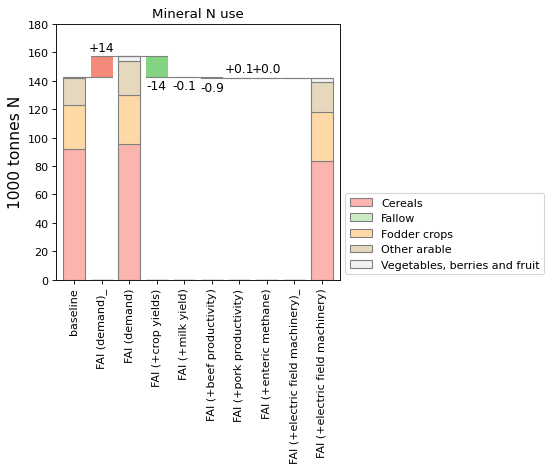

In [10]:
fig, ax = plt.subplots(figsize=(7,6), dpi=80)

plot_data3 = (
    (session.get_attr('C','fertiliser.mineral_N',groupby={'crop':'crop_group2'})/1000000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1)
    .droplevel('year')
)

plot.waterfall(
    data=plot_data3,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Mineral N use')
ax.tick_params(axis='y', which='major')
ax.set_xlabel('')
ax.set_ylabel('1000 tonnes N', size=14)
ax.set_ylim(top=180)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.show()